# Proceso de generación de parches

En esta parte se prepara una versión del dataset basada en parches de las imágenes originales, La idea es dividir cada imagen completa en regiones más pequeñas para que el modelo pueda trabajar con más detalle visual esto puede ayudar en la detección de kanjis, ya que muchos caracteres aparecen pequeños dentro de la imagen completa, Antes de entrenar el modelo con estos parches, se revisan las rutas, los parámetros de generación y la correspondencia entre imágenes y etiquetas.

In [15]:
from pathlib import Path

# Rutas base
ruta_original = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_original")
ruta_salida = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_parches/originales")

print("Existe origen:", ruta_original.exists())
print("Existe salida:", ruta_salida.exists())

Existe origen: True
Existe salida: False


## Revisión de la estructura del dataset original

Antes de generar los parches, se revisa que el dataset original tenga correctamente las carpetas de imágenes y etiquetas para train, val y test

In [16]:
for split in ["train", "val", "test"]:
    img_dir = ruta_original / "images" / split
    label_dir = ruta_original / "labels" / split

    print(f"\n{split.upper()}")
    print("Imágenes:", img_dir.exists(), len(list(img_dir.glob("*"))) if img_dir.exists() else 0)
    print("Labels:", label_dir.exists(), len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0)


TRAIN
Imágenes: True 55
Labels: True 55

VAL
Imágenes: True 10
Labels: True 10

TEST
Imágenes: True 10
Labels: True 10


## Crear carpetas de salida

Se crean las carpetas necesarias para guardar los parches generados, separadas por split (train, val, test) y por imágenes y labels.

In [17]:
# Crear estructura de carpetas para el dataset de parches
for split in ["train", "val", "test"]:
    (ruta_salida / "images" / split).mkdir(parents=True, exist_ok=True)
    (ruta_salida / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Carpetas creadas en:", ruta_salida)

Carpetas creadas en: /home/salvarado/TFM/Dataset_preparados/dataset_kanji_parches/originales


## Análisis de creacion de carpetas

Las carpetas se crean correctamente para los tres splits (train, val, test), tanto para imágenes como para labels, esta estructura es la que requiere YOLO 
para entrenar.

In [19]:
for split in ["train", "val", "test"]:
    print(split)
    print(" images:", (ruta_salida / "images" / split).exists())
    print(" labels:", (ruta_salida / "labels" / split).exists())

train
 images: True
 labels: True
val
 images: True
 labels: True
test
 images: True
 labels: True


## Prueba con una imagen

Antes de procesar todo el dataset, se analiza una imagen para conocer su tamaño real y el número de bounding boxes anotadas.

In [28]:
import cv2
import glob

# Coger una imagen de train
img_path = sorted(glob.glob(str(ruta_original / "images/train/*.png")))[0]
label_path = img_path.replace("images", "labels").replace(".png", ".txt")

img = cv2.imread(img_path)
h, w = img.shape[:2]

with open(label_path, "r") as f:
    lines = f.readlines()

print(f"Imagen: {img_path}")
print(f"Tamaño: {w} x {h} px")
print(f"Número de kanjis: {len(lines)}")

Imagen: /home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_original/images/train/sakuma-0458_Page_24.png
Tamaño: 9922 x 7012 px
Número de kanjis: 348


## Análisis de prueba de imagen

La imagen tiene un tamaño de 9922 x 7012 píxeles, lo que es muy grande para YOLO. Con imgsz=640 los kanjis se reducen drásticamente y el modelo tiene dificultades para detectarlos. Con 348 kanjis anotados por imagen, es un dataset denso que requiere buena resolución para aprender correctamente.

## Obtener medidas de los kanjis

Las labels de YOLO están normalizadas entre 0 y 1. Se convierten a píxeles reales para conocer el tamaño aproximado de los kanjis en la imagen original.
Conocer este tamaño es importante porque YOLO redimensiona la imagen antes de procesarla según el parámetro imgsz. Cuanto mayor sea la reducción, más pequeños quedan los kanjis y más difícil es detectarlos.

In [31]:
print("Tamaño aproximado de los kanjis en la imagen original:")
print()

for line in lines[:10]:
    datos = line.split()
    ancho_px = float(datos[3]) * w
    alto_px = float(datos[4]) * h
    print(f"Kanji: {round(ancho_px)} x {round(alto_px)} px")

print()
print("Tamaño aproximado del kanji más pequeño (133 px) según imgsz:")
print()

for imgsz in [640, 1280, 1600]:
    tamaño_reducido = 133 * (imgsz / w)
    print(f"imgsz={imgsz}: {tamaño_reducido:.1f} px")

Tamaño aproximado de los kanjis en la imagen original:

Kanji: 133 x 85 px
Kanji: 105 x 77 px
Kanji: 102 x 82 px
Kanji: 204 x 178 px
Kanji: 160 x 154 px
Kanji: 283 x 152 px
Kanji: 321 x 231 px
Kanji: 224 x 207 px
Kanji: 243 x 255 px
Kanji: 189 x 122 px

Tamaño aproximado del kanji más pequeño (133 px) según imgsz:

imgsz=640: 8.6 px
imgsz=1280: 17.2 px
imgsz=1600: 21.4 px


## Análisis medidas kanjis
Los kanjis miden entre 100 y 300 píxeles en la imagen original. Al reducir la imagen según imgsz, el kanji más pequeño (133 px) queda en:

- imgsz=640: 8.6 px
- imgsz=1280: 17.2 px  
- imgsz=1600: 21.4 px

Incluso con imgsz=1600 los kanjis quedan muy pequeños, lo que explica por qué el modelo tiene dificultades para detectarlos en imágenes completas. Esto justifica la estrategia de parches.

## Definición de parámetros de los parches

- patch_size=2048: los kanjis quedan a ~41 px dentro del parche, el doble que con imgsz=1600 sobre imagen completa [133 × (640 / 2048) ≈ 41 px] 
- overlap=512: 25% de solapamiento para no perder kanjis en los bordes
- step=1536: cuánto avanza cada parche

In [22]:
patch_size = 2048
overlap = 512
step = patch_size - overlap

print("Patch size:", patch_size)
print("Overlap:", overlap)
print("Step:", step)

Patch size: 2048
Overlap: 512
Step: 1536


## Prueba de generación de parches

Se prueba con una imagen para ver cuántos parches se generan con los parámetros definidos.

In [32]:
import cv2

patches = []

for y in range(0, h, step):
    for x in range(0, w, step):
        patch = img[y:y+patch_size, x:x+patch_size]

        # Evitar parches muy pequeños
        if patch.shape[0] < 1000 or patch.shape[1] < 1000:
            continue

        patches.append((patch, x, y))

print("Número de parches generados:", len(patches))

Número de parches generados: 24


## Análisis generacion de parches

Cada imagen genera 24 parches con 55 imágenes de train, 10 de val y 10 de test:

- Train: 55 × 24 = 1320 parches
- Val: 10 × 24 = 240 parches
- Test: 10 × 24 = 240 parches

El dataset pasa de 75 imágenes a 1800 parches, lo que multiplica significativamente los datos de entrenamiento.

## Visualización de parches

Se visualizan los primeros 4 parches generados para comprobar que el recorte es correcto

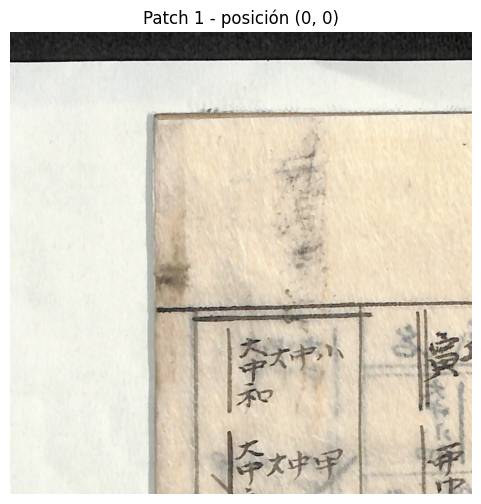

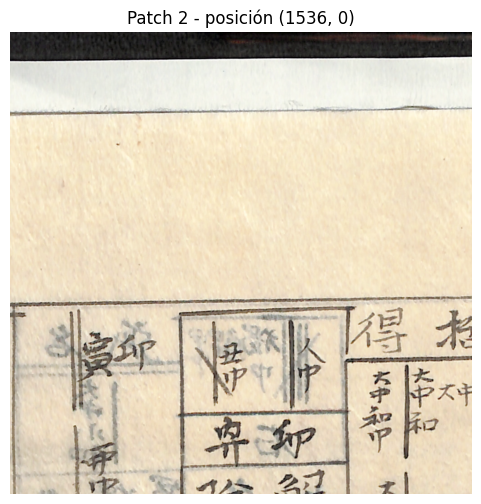

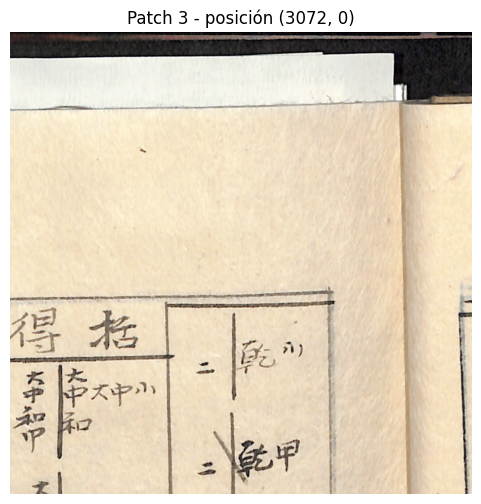

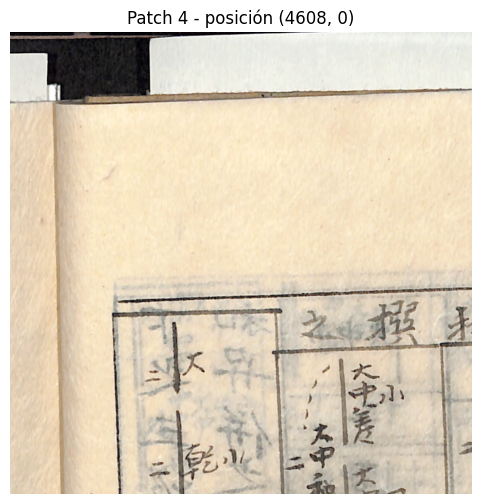

In [24]:
import matplotlib.pyplot as plt

for i, (patch, x, y) in enumerate(patches[:4]):
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
    plt.title(f"Patch {i+1} - posición ({x}, {y})")
    plt.axis("off")
    plt.show()

## Análisis

Los parches se generan correctamente cubriendo diferentes zonas de la imagen cada parche mide 2048 x 2048 px y avanza 1536 px respecto al anterior.
El solapamiento de 512 px funciona bien: los kanjis que aparecen cortados en el borde derecho del Patch 1 (posición 0,0) aparecen completos en el Patch 2 (posición 1536,0), confirmando que ningún kanji se pierde entre parches

## Revisión de si un kanji está en un recorte

Se dibuja el parche 8 con sus bounding boxes para verificar que el algoritmo asigna correctamente los kanjis a cada parche antes de procesar todo el dataset.

In [33]:
# Para cada parche, buscar qué kanjis caen dentro
for i, (patch, x, y) in enumerate(patches):

    ph, pw = patch.shape[:2]  # alto y ancho del parche
    cajas_parche = []

    for line in lines:
        datos = line.split()
        clase = int(datos[0])
        cx = float(datos[1]) * w   # centro x en píxeles
        cy = float(datos[2]) * h   # centro y en píxeles
        bw = float(datos[3]) * w   # ancho en píxeles
        bh = float(datos[4]) * h   # alto en píxeles

        # ¿El centro del kanji cae dentro de este parche?
        if x <= cx <= x + pw and y <= cy <= y + ph:
            # Recalcular coordenadas relativas al parche
            nuevo_cx = (cx - x) / pw
            nuevo_cy = (cy - y) / ph
            nuevo_bw = bw / pw
            nuevo_bh = bh / ph
            cajas_parche.append(f"0 {nuevo_cx:.6f} {nuevo_cy:.6f} {nuevo_bw:.6f} {nuevo_bh:.6f}")

    print(f"Parche {i+1} en ({x},{y}): {len(cajas_parche)} kanjis")

Parche 1 en (0,0): 12 kanjis
Parche 2 en (1536,0): 22 kanjis
Parche 3 en (3072,0): 19 kanjis
Parche 4 en (4608,0): 17 kanjis
Parche 5 en (6144,0): 30 kanjis
Parche 6 en (7680,0): 14 kanjis
Parche 7 en (0,1536): 26 kanjis
Parche 8 en (1536,1536): 52 kanjis
Parche 9 en (3072,1536): 37 kanjis
Parche 10 en (4608,1536): 34 kanjis
Parche 11 en (6144,1536): 47 kanjis
Parche 12 en (7680,1536): 29 kanjis
Parche 13 en (0,3072): 23 kanjis
Parche 14 en (1536,3072): 48 kanjis
Parche 15 en (3072,3072): 47 kanjis
Parche 16 en (4608,3072): 17 kanjis
Parche 17 en (6144,3072): 16 kanjis
Parche 18 en (7680,3072): 5 kanjis
Parche 19 en (0,4608): 17 kanjis
Parche 20 en (1536,4608): 41 kanjis
Parche 21 en (3072,4608): 38 kanjis
Parche 22 en (4608,4608): 14 kanjis
Parche 23 en (6144,4608): 15 kanjis
Parche 24 en (7680,4608): 1 kanjis


## Revisión de si un kanji está en un recorte

Se dibuja el parche 8 con sus bounding boxes para verificar que el algoritmo asigna correctamente los kanjis a cada parche antes de procesar todo el dataset.

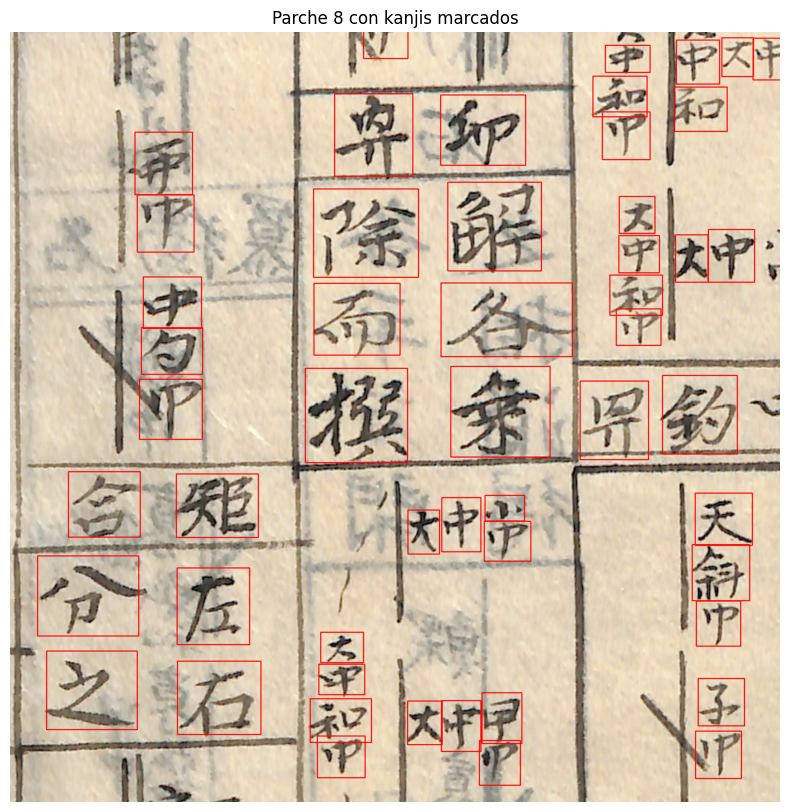

In [34]:
import matplotlib.pyplot as plt
import cv2

# Coger el parche 8 (tiene muchos kanjis)
patch, x, y = patches[7]
alto_p, ancho_p = patch.shape[:2]

# Dibujar las cajas de los kanjis que caen en este parche
imagen_dibujo = patch.copy()

for line in lines:
    datos = line.split()
    cx = float(datos[1]) * w
    cy = float(datos[2]) * h
    bw = float(datos[3]) * w
    bh = float(datos[4]) * h

    # Si el centro del kanji está dentro del parche
    if x <= cx <= x + ancho_p and y <= cy <= y + alto_p:
        # Esquina superior izquierda y inferior derecha dentro del parche
        x1 = int(cx - bw/2 - x)
        y1 = int(cy - bh/2 - y)
        x2 = int(cx + bw/2 - x)
        y2 = int(cy + bh/2 - y)
        cv2.rectangle(imagen_dibujo, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(imagen_dibujo, cv2.COLOR_BGR2RGB))
plt.title(f"Parche 8 con kanjis marcados")
plt.axis('off')
plt.show()

## Análisis

Las bounding boxes se dibujan correctamente sobre los kanjis del parche 8 ,las cajas están bien alineadas con cada carácter, confirmando que el algoritmo de asignación de coordenadas funciona correctamente y podemos proceder a generar el dataset completo.

## Generación del dataset completo

Se procesan todas las imágenes de train, val y test generando los parches y sus labels correspondientes.

In [35]:
import cv2
import os

# Procesar train, val y test
for split in ['train', 'val', 'test']:
    
    # Rutas de entrada y salida
    carpeta_imagenes = ruta_original / "images" / split
    carpeta_labels = ruta_original / "labels" / split
    carpeta_salida_img = ruta_salida / "images" / split
    carpeta_salida_lab = ruta_salida / "labels" / split

    total_parches = 0

    # Procesar cada imagen
    for nombre in os.listdir(carpeta_imagenes):
        if not nombre.endswith(".png"):
            continue

        # Leer imagen y sus labels
        img = cv2.imread(str(carpeta_imagenes / nombre))
        h, w = img.shape[:2]

        with open(str(carpeta_labels / nombre.replace(".png", ".txt")), "r") as f:
            lines = f.readlines()

        num_parche = 0

        # Cortar la imagen en parches
        for y in range(0, h, step):
            for x in range(0, w, step):
                patch = img[y:y+patch_size, x:x+patch_size]

                # Ignorar parches muy pequeños (bordes de imagen)
                if patch.shape[0] < 1000 or patch.shape[1] < 1000:
                    continue

                ph, pw = patch.shape[:2]
                cajas = []

                # Buscar qué kanjis caen dentro de este parche
                for line in lines:
                    datos = line.split()
                    cx = float(datos[1]) * w  # centro x en píxeles
                    cy = float(datos[2]) * h  # centro y en píxeles
                    bw = float(datos[3]) * w  # ancho en píxeles
                    bh = float(datos[4]) * h  # alto en píxeles

                    # Si el centro del kanji cae dentro del parche
                    if x <= cx <= x + pw and y <= cy <= y + ph:
                        # Recalcular coordenadas relativas al parche
                        nuevo_cx = (cx - x) / pw
                        nuevo_cy = (cy - y) / ph
                        nuevo_bw = bw / pw
                        nuevo_bh = bh / ph
                        cajas.append(f"0 {nuevo_cx:.6f} {nuevo_cy:.6f} {nuevo_bw:.6f} {nuevo_bh:.6f}")

                # Guardar parche e imagen
                nombre_parche = nombre.replace(".png", f"_p{num_parche}.png")
                cv2.imwrite(str(carpeta_salida_img / nombre_parche), patch)

                # Guardar labels del parche
                with open(str(carpeta_salida_lab / nombre_parche.replace(".png", ".txt")), "w") as f:
                    f.write("\n".join(cajas))

                num_parche += 1
                total_parches += 1

        print(f"{nombre}: {num_parche} parches")

    print(f"\nTotal parches {split}: {total_parches}\n")

sakuma-0513_Page_05.png: 24 parches
sakuma-0458_Page_24.png: 24 parches
sakuma-0472_Page_05.png: 24 parches
sakuma-0469_Page_27.png: 24 parches
sakuma-0513_Page_10.png: 24 parches
sakuma-0470_Page_15.png: 24 parches
sakuma-0472_Page_25.png: 24 parches
sakuma-0581_Page_03.png: 24 parches
sakuma-0469_Page_19.png: 24 parches
sakuma-0472_Page_23.png: 24 parches
sakuma-0581_Page_15.png: 24 parches
sakuma-0470_Page_16.png: 24 parches
sakuma-0469_Page_20.png: 24 parches
sakuma-0472_Page_27.png: 24 parches
sakuma-0513_Page_09.png: 24 parches
sakuma-0469_Page_04.png: 24 parches
sakuma-0472_Page_24.png: 24 parches
sakuma-0470_Page_03.png: 24 parches
sakuma-0581_Page_06.png: 24 parches
sakuma-0513_Page_36.png: 24 parches
sakuma-0581_Page_31.png: 24 parches
sakuma-0581_Page_20.png: 24 parches
sakuma-0513_Page_13.png: 24 parches
sakuma-0470_Page_18.png: 24 parches
sakuma-0581_Page_07.png: 24 parches
sakuma-0469_Page_21.png: 24 parches
sakuma-0581_Page_08.png: 24 parches
sakuma-0472_Page_04.png: 24 

In [36]:
for split in ["train", "val", "test"]:
    imgs = list((ruta_salida / "images" / split).glob("*.png"))
    labs = list((ruta_salida / "labels" / split).glob("*.txt"))

    print(split)
    print("Imágenes:", len(imgs))
    print("Labels:", len(labs))
    print()

train
Imágenes: 1320
Labels: 1320

val
Imágenes: 240
Labels: 240

test
Imágenes: 240
Labels: 240



## Análisis

Se generaron correctamente los parches para los tres splits tanto imagenes como labels

- Train: 1320 parches (55 imágenes × 24 parches)
- Val: 240 parches (10 imágenes × 24 parches)
- Test: 240 parches (10 imágenes × 24 parches)

Total: 1800 parches. El dataset pasó de 75 imágenes originales a 1800 parches, multiplicando significativamente los datos de entrenamiento.

## Generacion de archivo yaml

In [37]:
with open(ruta_salida / "dataset_parches_originales.yaml", "w") as f:
    f.write(f"""
path: {ruta_salida}
train: images/train
val: images/val
test: images/test

names:
  0: kanji
""")

print("YAML creado")

YAML creado


## Generación de parches - Dataset Denoised

Se repite el mismo proceso para las imágenes denoised.

In [1]:
from pathlib import Path

ruta_denoised = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_denoised")
ruta_salida_denoised = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_parches/denoised")

print("Existe origen:", ruta_denoised.exists())
print("Existe salida:", ruta_salida_denoised.exists())

Existe origen: True
Existe salida: False


# Se crean las capetas de denoised

In [2]:
import os

for split in ['train', 'val', 'test']:
    os.makedirs(ruta_salida_denoised / "images" / split, exist_ok=True)
    os.makedirs(ruta_salida_denoised / "labels" / split, exist_ok=True)

print("Carpetas creadas")

Carpetas creadas


In [4]:
for split in ["train", "val", "test"]:
    print(split)
    print(" images:", (ruta_salida_denoised / "images" / split).exists())
    print(" labels:", (ruta_salida_denoised / "labels" / split).exists())

train
 images: True
 labels: True
val
 images: True
 labels: True
test
 images: True
 labels: True


## Prueba con una imagen de denoised 

Antes de procesar todo el dataset, se analiza una imagen para conocer su tamaño real y el número de bounding boxes anotadas.

In [5]:
import cv2
import glob

img_path = sorted(glob.glob(str(ruta_denoised / "images/train/*.png")))[0]
label_path = img_path.replace("images", "labels").replace(".png", ".txt")

img = cv2.imread(img_path)
h, w = img.shape[:2]

with open(label_path, "r") as f:
    lines = f.readlines()

print(f"Imagen: {img_path}")
print(f"Tamaño: {w} x {h} px")
print(f"Número de kanjis: {len(lines)}")

Imagen: /home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_denoised/images/train/sakuma-0458_Page_24denoised.png
Tamaño: 9922 x 7012 px
Número de kanjis: 348


## Análisis

El dataset denoised tiene el mismo tamaño de imagen (9922 x 7012 px) y el mismo número de kanjis anotados (348) que el dataset original. Esto confirma que ambos datasets son comparables y se pueden usar con los mismos parámetros de parches.

## Obtener medidas de los kanjis

Al ser el mismo dataset pero con preprocesado de reducción de ruido, los kanjis tienen el mismo tamaño en píxeles que en el dataset original. Los parámetros de parches definidos anteriormente (patch_size=2048, overlap=512) aplican igual.

## Parámetros de los parches

Se usan los mismos parámetros que en el dataset original.

In [6]:
patch_size = 2048
overlap = 512
step = patch_size - overlap

print("Patch size:", patch_size)
print("Overlap:", overlap)
print("Step:", step)

Patch size: 2048
Overlap: 512
Step: 1536


## Prueba de generación de parches con  denoised

Se prueba con una imagen para ver cuántos parches se generan con los parámetros definidos.

In [7]:
patches_denoised = []

for y in range(0, h, step):
    for x in range(0, w, step):
        patch = img[y:y+patch_size, x:x+patch_size]
        if patch.shape[0] < 1000 or patch.shape[1] < 1000:
            continue
        patches_denoised.append((patch, x, y))

print("Número de parches generados:", len(patches_denoised))

Número de parches generados: 24


## Análisis

Se generan 24 parches por imagen, igual que en el dataset original. Los parámetros funcionan correctamente para las imágenes denoised.

## Visualización de parches

Se visualizan los primeros 4 parches para comprobar que el recorte es correcto.

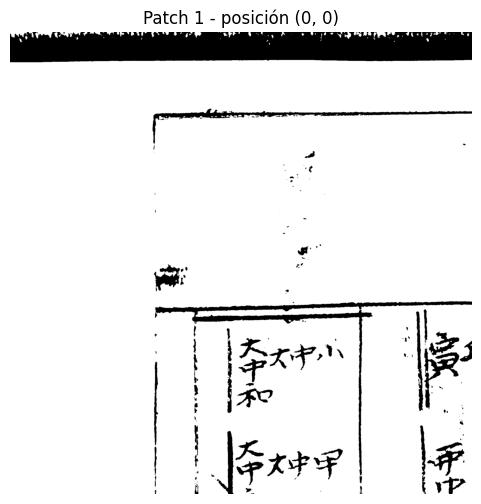

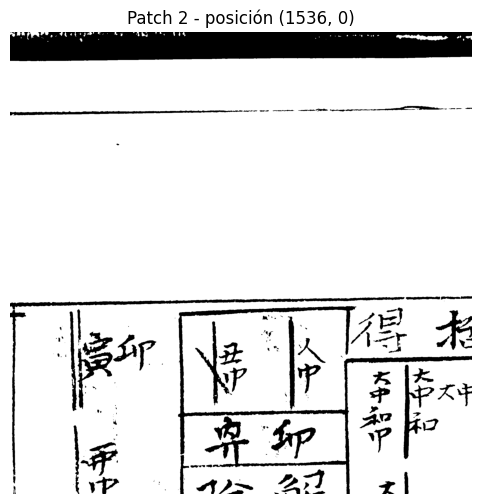

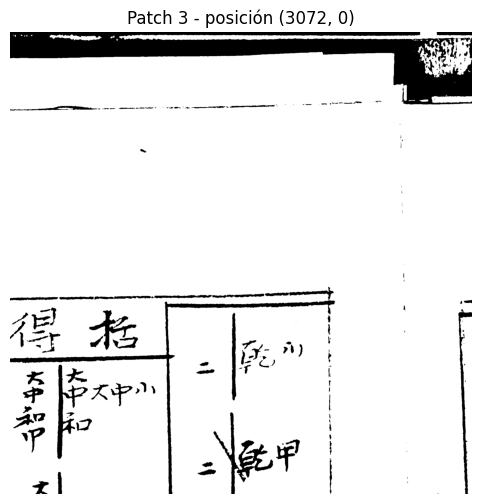

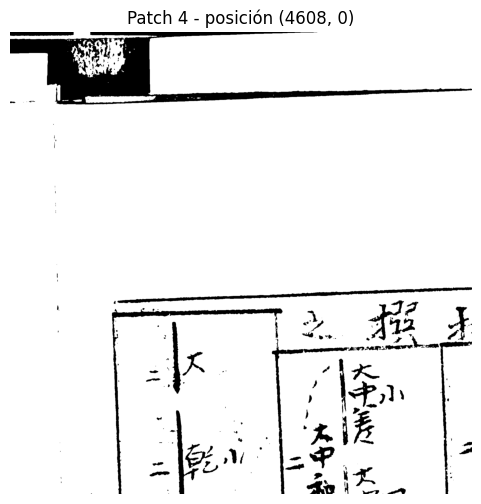

In [8]:
import matplotlib.pyplot as plt

for i, (patch, x, y) in enumerate(patches_denoised[:4]):
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
    plt.title(f"Patch {i+1} - posición ({x}, {y})")
    plt.axis("off")
    plt.show()

## Análisis

Los parches denoised se generan correctamente. Se aprecia visualmente la diferencia respecto al original: las imágenes denoised tienen mayor contraste y menos ruido de fondo, lo que facilita que el modelo distinga mejor los kanjis del resto de la imagen.

## Revisión de kanjis en los parches de denoised

Se comprueba cuántos kanjis caen en cada parche para verificar que el algoritmo de asignación funciona correctamente.

In [9]:
for i, (patch, x, y) in enumerate(patches_denoised):
    ph, pw = patch.shape[:2]
    cajas_parche = []

    for line in lines:
        datos = line.split()
        cx = float(datos[1]) * w
        cy = float(datos[2]) * h
        bw = float(datos[3]) * w
        bh = float(datos[4]) * h

        if x <= cx <= x + pw and y <= cy <= y + ph:
            cajas_parche.append(line)

    print(f"Parche {i+1} en ({x},{y}): {len(cajas_parche)} kanjis")

Parche 1 en (0,0): 12 kanjis
Parche 2 en (1536,0): 22 kanjis
Parche 3 en (3072,0): 19 kanjis
Parche 4 en (4608,0): 17 kanjis
Parche 5 en (6144,0): 30 kanjis
Parche 6 en (7680,0): 14 kanjis
Parche 7 en (0,1536): 26 kanjis
Parche 8 en (1536,1536): 52 kanjis
Parche 9 en (3072,1536): 37 kanjis
Parche 10 en (4608,1536): 34 kanjis
Parche 11 en (6144,1536): 47 kanjis
Parche 12 en (7680,1536): 29 kanjis
Parche 13 en (0,3072): 23 kanjis
Parche 14 en (1536,3072): 48 kanjis
Parche 15 en (3072,3072): 47 kanjis
Parche 16 en (4608,3072): 17 kanjis
Parche 17 en (6144,3072): 16 kanjis
Parche 18 en (7680,3072): 5 kanjis
Parche 19 en (0,4608): 17 kanjis
Parche 20 en (1536,4608): 41 kanjis
Parche 21 en (3072,4608): 38 kanjis
Parche 22 en (4608,4608): 14 kanjis
Parche 23 en (6144,4608): 15 kanjis
Parche 24 en (7680,4608): 1 kanjis


## Análisis

Los 24 parches tienen los mismos kanjis asignados que en el dataset original, lo cual es correcto ya que ambos datasets comparten las mismas anotaciones. Solo cambian las imágenes, no las labels.

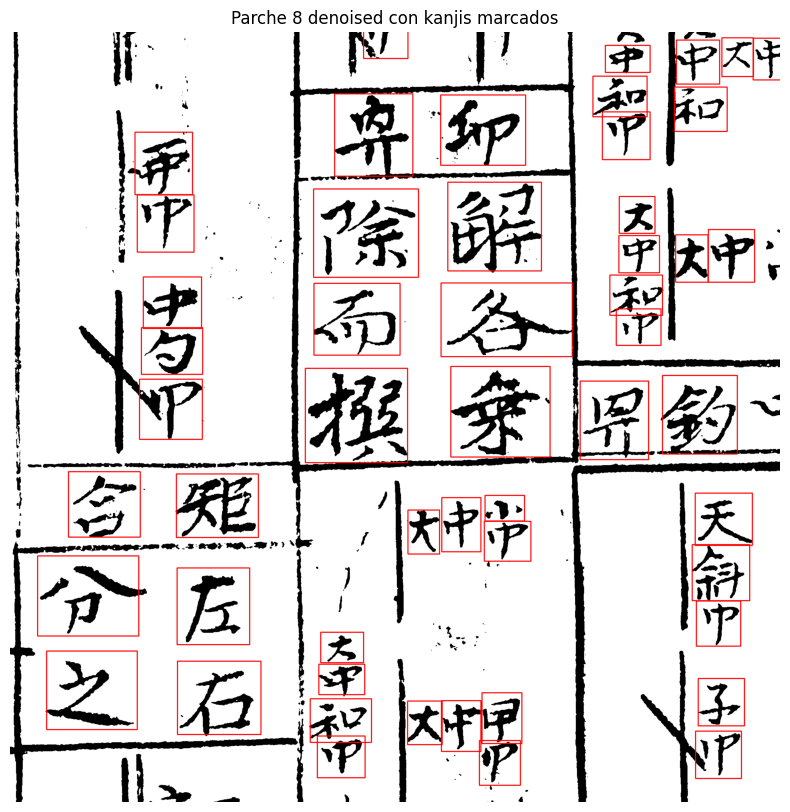

In [12]:
import matplotlib.pyplot as plt
import cv2

# Coger el parche 8 (tiene muchos kanjis)
patch, x, y = patches_denoised[7]
alto_p, ancho_p = patch.shape[:2]

# Dibujar las cajas de los kanjis que caen en este parche
imagen_dibujo = patch.copy()

for line in lines:
    datos = line.split()
    cx = float(datos[1]) * w
    cy = float(datos[2]) * h
    bw = float(datos[3]) * w
    bh = float(datos[4]) * h

    # Si el centro del kanji está dentro del parche
    if x <= cx <= x + ancho_p and y <= cy <= y + alto_p:
        x1 = int(cx - bw/2 - x)
        y1 = int(cy - bh/2 - y)
        x2 = int(cx + bw/2 - x)
        y2 = int(cy + bh/2 - y)
        cv2.rectangle(imagen_dibujo, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(imagen_dibujo, cv2.COLOR_BGR2RGB))
plt.title("Parche 8 denoised con kanjis marcados")
plt.axis('off')
plt.show()

## Generación del dataset completo denoised

Se procesan todas las imágenes denoised de train, val y test generando los parches y sus labels correspondientes.

In [13]:
import cv2
import os

# Procesar train, val y test para denoised
for split in ['train', 'val', 'test']:
    
    # Rutas de entrada y salida denoised
    carpeta_imagenes = ruta_denoised / "images" / split
    carpeta_labels = ruta_denoised / "labels" / split
    carpeta_salida_img = ruta_salida_denoised / "images" / split
    carpeta_salida_lab = ruta_salida_denoised / "labels" / split

    total_parches = 0

    # Procesar cada imagen
    for nombre in os.listdir(carpeta_imagenes):
        if not nombre.endswith(".png"):
            continue

        # Leer imagen y sus labels
        img = cv2.imread(str(carpeta_imagenes / nombre))
        h, w = img.shape[:2]

        with open(str(carpeta_labels / nombre.replace(".png", ".txt")), "r") as f:
            lines = f.readlines()

        num_parche = 0

        # Cortar la imagen en parches
        for y in range(0, h, step):
            for x in range(0, w, step):
                patch = img[y:y+patch_size, x:x+patch_size]

                # Ignorar parches muy pequeños (bordes de imagen)
                if patch.shape[0] < 1000 or patch.shape[1] < 1000:
                    continue

                ph, pw = patch.shape[:2]
                cajas = []

                # Buscar qué kanjis caen dentro de este parche
                for line in lines:
                    datos = line.split()
                    cx = float(datos[1]) * w  # centro x en píxeles
                    cy = float(datos[2]) * h  # centro y en píxeles
                    bw = float(datos[3]) * w  # ancho en píxeles
                    bh = float(datos[4]) * h  # alto en píxeles

                    # Si el centro del kanji cae dentro del parche
                    if x <= cx <= x + pw and y <= cy <= y + ph:
                        # Recalcular coordenadas relativas al parche
                        nuevo_cx = (cx - x) / pw
                        nuevo_cy = (cy - y) / ph
                        nuevo_bw = bw / pw
                        nuevo_bh = bh / ph
                        cajas.append(f"0 {nuevo_cx:.6f} {nuevo_cy:.6f} {nuevo_bw:.6f} {nuevo_bh:.6f}")

                # Guardar parche e imagen
                nombre_parche = nombre.replace(".png", f"_p{num_parche}.png")
                cv2.imwrite(str(carpeta_salida_img / nombre_parche), patch)

                # Guardar labels del parche
                with open(str(carpeta_salida_lab / nombre_parche.replace(".png", ".txt")), "w") as f:
                    f.write("\n".join(cajas))

                num_parche += 1
                total_parches += 1

        print(f"{nombre}: {num_parche} parches")

    print(f"\nTotal parches {split}: {total_parches}\n")

sakuma-0581_Page_08denoised.png: 24 parches
sakuma-0513_Page_36denoised.png: 24 parches
sakuma-0581_Page_17denoised.png: 24 parches
sakuma-0513_Page_12denoised.png: 24 parches
sakuma-0581_Page_06denoised.png: 24 parches
sakuma-0581_Page_03denoised.png: 24 parches
sakuma-0581_Page_04denoised.png: 24 parches
sakuma-0513_Page_05denoised.png: 24 parches
sakuma-0581_Page_15denoised.png: 24 parches
sakuma-0513_Page_35denoised.png: 24 parches
sakuma-0581_Page_02denoised.png: 24 parches
sakuma-0472_Page_24denoised.png: 24 parches
sakuma-0513_Page_10denoised.png: 24 parches
sakuma-0581_Page_20denoised.png: 24 parches
sakuma-0472_Page_03denoised.png: 24 parches
sakuma-0581_Page_30denoised.png: 24 parches
sakuma-0581_Page_32denoised.png: 24 parches
sakuma-0469_Page_03denoised.png: 24 parches
sakuma-0472_Page_27denoised.png: 24 parches
sakuma-0581_Page_16denoised.png: 24 parches
sakuma-0469_Page_20denoised.png: 24 parches
sakuma-0513_Page_08denoised.png: 24 parches
sakuma-0581_Page_07denoised.png:

In [14]:
for split in ["train", "val", "test"]:
    imgs = list((ruta_salida_denoised / "images" / split).glob("*.png"))
    labs = list((ruta_salida_denoised / "labels" / split).glob("*.txt"))

    print(split)
    print("Imágenes:", len(imgs))
    print("Labels:", len(labs))
    print()

train
Imágenes: 1320
Labels: 1320

val
Imágenes: 240
Labels: 240

test
Imágenes: 240
Labels: 240



## Análisis

Se generaron correctamente los parches denoised para los tres splits:

- Train: 1320 parches ✅
- Val: 240 parches ✅
- Test: 240 parches ✅

Además se verifica que cada imagen tiene su label correspondiente, confirmando que el dataset está completo y listo para entrenar.

## Crear yaml para YOLO para denoised 

Se crea el archivo de configuración para el dataset de parches denoised.

In [15]:
with open(ruta_salida_denoised / "dataset_parches_denoised.yaml", "w") as f:
    f.write(f"""
path: {ruta_salida_denoised}
train: images/train
val: images/val
test: images/test

names:
  0: kanji
""")

print("YAML creado")

YAML creado
